# Manual tries: Claude vs. Copilot

Compares the two manual result files in `data/manual_tries/` (one per model) on:
- how many restaurant menus each model found (`hasFoundMenu`)
- how many menu links the models agree on, and where/how they differ

In [101]:
import json
import pandas as pd
from foodscraper.config import *
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
plt.style.use('seaborn-v0_8-pastel')


In [102]:
manual_tries_dir = DATA_DIR / "manual_tries_20_only"
files = sorted(manual_tries_dir.glob("*.json"))

dfs = []
for f in files:
    model = f.stem
    records = json.loads(f.read_text())
    d = pd.DataFrame(records)
    d["model"] = model
    dfs.append(d)

df = pd.concat(dfs, ignore_index=True)
models = sorted(df["model"].unique())
print(f"models: {models}")
df.head(10)

models: ['20260916-claude-1', '20260916-claude-1-verified', '20260916-claude-2', '20260916-claude-2-verified', '20260916-claude-3', '20260916-claude-3-verified', '20260916-copilot-1', '20260916-copilot-1-verified', '20260916-copilot-2', '20260916-copilot-2-verified', '20260916-copilot-3', '20260916-copilot-3-verified']


,id,name,hasFoundMenu,menuLink,format,source,manualVerification,correctMenuLink,model
0,ChIJRzRI2vNTUkYRRndb0XtBWow,Berlin Döner,True,https://wolt.com/en/dnk/copenhagen/restaurant/...,HTML,WOLT,suboptimal,https://berlindonercph.dk/menu/,20260916-claude-1-verified
1,ChIJq9PWX55TUkYRBGa7u0DJYvE,Ata Pizza,True,https://www.atapizzakebabhouse.dk/,HTML,OTHER_THIRD_PARTY,correct,NaN,20260916-claude-1-verified
2,ChIJn4ah93RTUkYRzi8qRSKEaAI,Sticks'n'Sushi - Restaurant Vesterbro,True,https://a.storyblok.com/f/286316/x/a7b0fc6a7f/...,PDF,OFFICIAL_WEBSITE,correct,NaN,20260916-claude-1-verified
3,ChIJr-oJ-HRTUkYRf4fbGF1hGR4,Skipper's Bodega,False,,,,correct,NaN,20260916-claude-1-verified
4,ChIJcR5brHVTUkYR80HGten90uY,Auténtica Twuería Mexicana,False,,,,correct,NaN,20260916-claude-1-verified
5,ChIJDZwnIJ5TUkYRbei1mqKLQ8I,Cafe Erik,False,,,,correct,NaN,20260916-claude-1-verified
6,ChIJk5HSlzNTUkYRVuHEAOh6I4s,La Neta Vesterbro,True,https://www.laneta.dk/menu,HTML,OFFICIAL_WEBSITE,correct,NaN,20260916-claude-1-verified
7,ChIJyUPdsXVTUkYR7Jtb_vDeMAs,Isted Grill,True,https://istedgrill.dk/menu/,HTML,OFFICIAL_WEBSITE,correct,NaN,20260916-claude-1-verified
8,ChIJdcbStnVTUkYRVaGtDg9A2vc,Ankara Durum House,True,https://wolt.com/en/dnk/copenhagen/restaurant/...,HTML,WOLT,correct,NaN,20260916-claude-1-verified
9,ChIJgUgIXCJTUkYROUvU9Ogpqmk,GAO Dumpling Bar,True,https://wolt.com/en/dnk/copenhagen/restaurant/...,HTML,WOLT,suboptimal,https://gaodumpling.com/istedgade,20260916-claude-1-verified


## How many menus did each model find?

In [103]:
found_summary = (
    df.groupby("model")["hasFoundMenu"]
    .agg(n_restaurants="size", n_found="sum")
    .assign(found_rate=lambda d: d["n_found"] / d["n_restaurants"])
)
found_summary.sort_values("found_rate", ascending=False)

,n_restaurants,n_found,found_rate
model,,,
20260916-claude-1,20,14,0.70
20260916-claude-1-verified,20,14,0.70
20260916-claude-2,20,14,0.70
20260916-claude-2-verified,20,14,0.70
20260916-claude-3,20,14,0.70
20260916-claude-3-verified,20,14,0.70
20260916-copilot-3,20,13,0.65
20260916-copilot-3-verified,20,13,0.65
20260916-copilot-2,20,12,0.60


## Where do the models agree / disagree on `menuLink`?

Each restaurant is classified as:
- `agree` — both models found the same link
- `both_not_found` — neither model found a menu
- `one_found_only` — one model found a link, the other didn't
- `different_link` — both found a menu, but at different URLs

In [104]:
def norm(url):
    if not isinstance(url, str) or not url.strip():
        return None
    return url.strip().rstrip("/").lower()


def classify(row):
    a, b = norm(row[models[0]]), norm(row[models[1]])
    if a is None and b is None:
        return "both_not_found"
    if a == b:
        return "agree"
    if a is None or b is None:
        return "one_found_only"
    return "different_link"


comparison = df.pivot_table(
    index=["id", "name"], columns="model", values="menuLink", aggfunc="first"
).reindex(columns=models)
comparison["status"] = comparison.apply(classify, axis=1)

comparison["status"].value_counts()

status
agree             14
both_not_found     6
Name: count, dtype: int64

In [105]:
comparison[comparison["status"] == "different_link"]

,model,20260916-claude-1,20260916-claude-1-verified,20260916-claude-2,20260916-claude-2-verified,20260916-claude-3,20260916-claude-3-verified,20260916-copilot-1,20260916-copilot-1-verified,20260916-copilot-2,20260916-copilot-2-verified,20260916-copilot-3,20260916-copilot-3-verified,status
id,name,,,,,,,,,,,,,


In [106]:
disagreements = (
    comparison[comparison["status"].isin(["different_link", "one_found_only"])]
    .sort_values("status")
)

disagreements

,model,20260916-claude-1,20260916-claude-1-verified,20260916-claude-2,20260916-claude-2-verified,20260916-claude-3,20260916-claude-3-verified,20260916-copilot-1,20260916-copilot-1-verified,20260916-copilot-2,20260916-copilot-2-verified,20260916-copilot-3,20260916-copilot-3-verified,status
id,name,,,,,,,,,,,,,


## Compare two specific models

Unlike the sections above (which always use the first two models alphabetically), this lets you pick any two models by name.

In [107]:
def compare_two_models(df, model_a, model_b):
    pair = [model_a, model_b]

    summary = (
        df[df["model"].isin(pair)]
        .groupby("model")["hasFoundMenu"]
        .agg(n_restaurants="size", n_found="sum")
        .assign(found_rate=lambda d: d["n_found"] / d["n_restaurants"])
        .reindex(pair)
    )

    pivot = df.pivot_table(
        index=["id", "name"], columns="model", values="menuLink", aggfunc="first"
    ).reindex(columns=pair)

    def classify(row):
        a, b = norm(row[model_a]), norm(row[model_b])
        if a is None and b is None:
            return "both_not_found"
        if a == b:
            return "agree"
        if a is None or b is None:
            return "one_found_only"
        return "different_link"

    pivot["status"] = pivot.apply(classify, axis=1)
    return summary, pivot


model_a, model_b = "20260914-copilot-1", "20260914-copilot-1-shortprompt"
pair_summary, pair_comparison = compare_two_models(df, model_a, model_b)
pair_summary

,n_restaurants,n_found,found_rate
model,,,
20260914-copilot-1,NaN,NaN,NaN
20260914-copilot-1-shortprompt,NaN,NaN,NaN


In [108]:
pair_comparison["status"].value_counts()

status
both_not_found    20
Name: count, dtype: int64

In [109]:
# rows where the two disagree
pair_comparison[pair_comparison["status"].isin(["different_link", "one_found_only"])]

,model,20260914-copilot-1,20260914-copilot-1-shortprompt,status
id,name,,,


## Manual verification: correct vs. incorrect vs. suboptimal

Uses the `-verified` files only (each row has been manually checked against `correctMenuLink`).

In [110]:
verified_files = sorted(manual_tries_dir.glob("*-verified.json"))

vdfs = []
for f in verified_files:
    model = f.stem.removesuffix("-verified")
    records = json.loads(f.read_text())
    d = pd.DataFrame(records)
    d["model"] = model
    vdfs.append(d)

vdf = pd.concat(vdfs, ignore_index=True)
verification_order = ["correct", "suboptimal", "incorrect"]
vdf["manualVerification"] = pd.Categorical(
    vdf["manualVerification"], categories=verification_order, ordered=True
)
vdf.head(10)

,id,name,hasFoundMenu,menuLink,format,source,manualVerification,correctMenuLink,model
0,ChIJRzRI2vNTUkYRRndb0XtBWow,Berlin Döner,True,https://wolt.com/en/dnk/copenhagen/restaurant/...,HTML,WOLT,suboptimal,https://berlindonercph.dk/menu/,20260916-claude-1
1,ChIJq9PWX55TUkYRBGa7u0DJYvE,Ata Pizza,True,https://www.atapizzakebabhouse.dk/,HTML,OTHER_THIRD_PARTY,correct,NaN,20260916-claude-1
2,ChIJn4ah93RTUkYRzi8qRSKEaAI,Sticks'n'Sushi - Restaurant Vesterbro,True,https://a.storyblok.com/f/286316/x/a7b0fc6a7f/...,PDF,OFFICIAL_WEBSITE,correct,NaN,20260916-claude-1
3,ChIJr-oJ-HRTUkYRf4fbGF1hGR4,Skipper's Bodega,False,,,,correct,NaN,20260916-claude-1
4,ChIJcR5brHVTUkYR80HGten90uY,Auténtica Twuería Mexicana,False,,,,correct,NaN,20260916-claude-1
5,ChIJDZwnIJ5TUkYRbei1mqKLQ8I,Cafe Erik,False,,,,correct,NaN,20260916-claude-1
6,ChIJk5HSlzNTUkYRVuHEAOh6I4s,La Neta Vesterbro,True,https://www.laneta.dk/menu,HTML,OFFICIAL_WEBSITE,correct,NaN,20260916-claude-1
7,ChIJyUPdsXVTUkYR7Jtb_vDeMAs,Isted Grill,True,https://istedgrill.dk/menu/,HTML,OFFICIAL_WEBSITE,correct,NaN,20260916-claude-1
8,ChIJdcbStnVTUkYRVaGtDg9A2vc,Ankara Durum House,True,https://wolt.com/en/dnk/copenhagen/restaurant/...,HTML,WOLT,correct,NaN,20260916-claude-1
9,ChIJgUgIXCJTUkYROUvU9Ogpqmk,GAO Dumpling Bar,True,https://wolt.com/en/dnk/copenhagen/restaurant/...,HTML,WOLT,suboptimal,https://gaodumpling.com/istedgade,20260916-claude-1


### Overall counts (all models combined)

In [111]:
overall_counts = vdf["manualVerification"].value_counts().reindex(verification_order)
overall_summary = pd.DataFrame(
    {
        "count": overall_counts,
        "rate": (overall_counts / len(vdf)).round(3),
    }
)
overall_summary

,count,rate
manualVerification,,
correct,85,0.708
suboptimal,9,0.075
incorrect,26,0.217


### Breakdown per model (counts and rates)

In [112]:
per_model_counts = pd.crosstab(vdf["model"], vdf["manualVerification"])[verification_order]
per_model_rates = per_model_counts.div(per_model_counts.sum(axis=1), axis=0).round(3)

per_model_summary = per_model_counts.join(
    per_model_rates, lsuffix="_n", rsuffix="_rate"
).reindex(
    columns=[c for pair in zip(
        [f"{v}_n" for v in verification_order], [f"{v}_rate" for v in verification_order]
    ) for c in pair]
)
per_model_summary

manualVerification,correct_n,correct_rate,suboptimal_n,suboptimal_rate,incorrect_n,incorrect_rate
model,,,,,,
20260916-claude-1,16,0.80,3,0.15,1,0.05
20260916-claude-2,16,0.80,3,0.15,1,0.05
20260916-claude-3,15,0.75,3,0.15,2,0.10
20260916-copilot-1,12,0.60,0,0.00,8,0.40
20260916-copilot-2,14,0.70,0,0.00,6,0.30
20260916-copilot-3,12,0.60,0,0.00,8,0.40


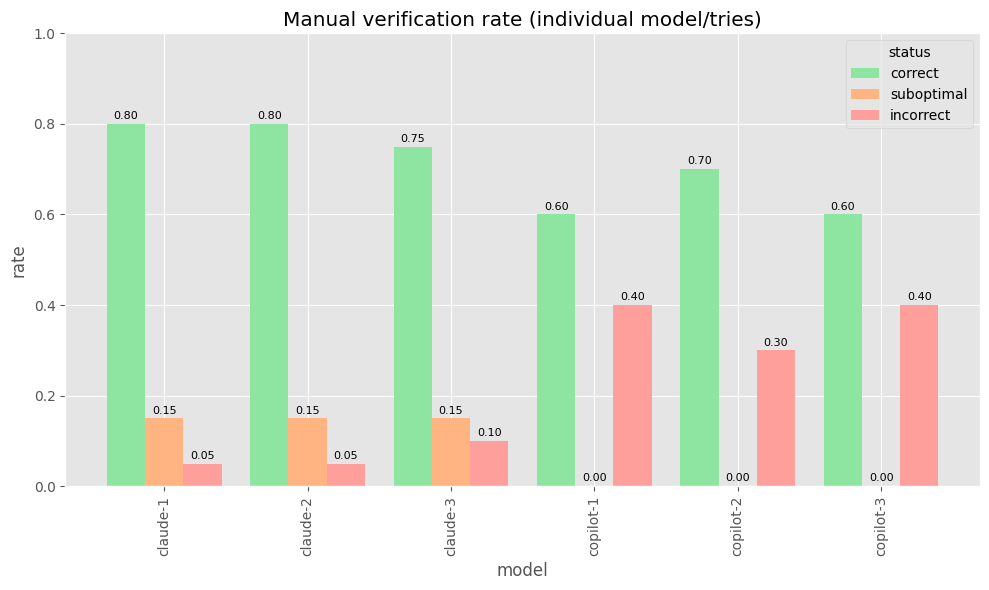

In [ ]:

pal = sns.color_palette('pastel')
colors = {"correct_rate": pal[2], "suboptimal_rate": pal[1], "incorrect_rate": pal[3]}

rate_cols = [f"{v}_rate" for v in verification_order]
plot_df = per_model_summary[rate_cols]
plot_labels = plot_df.index.str.replace(r"^\d{8}-", "", regex=True)

x = np.arange(len(plot_df.index))
n_bars = len(rate_cols)
bar_width = 0.8 / n_bars
colors = {"correct_rate": pal[2], "suboptimal_rate": pal[1], "incorrect_rate": pal[3]}

fig, ax = plt.subplots(figsize=(10, 6))

for i, col in enumerate(rate_cols):
    offset = (i - (n_bars - 1) / 2) * bar_width
    bars = ax.bar(
        x + offset, plot_df[col], bar_width,
        label=col.replace("_rate", ""), color=colors[col],
    )
    ax.bar_label(bars, labels=[f"{v:.2f}" for v in plot_df[col]], padding=2, fontsize=8)

ax.set_xlabel("model")
ax.set_ylabel("rate")
ax.set_title("Manual verification rate (individual model/tries)")
ax.set_xticks(x)
ax.set_xticklabels(plot_labels, rotation=90, ha="center")
ax.set_ylim(0, 1.0)
ax.legend(title="status")
fig.tight_layout()
plt.show()

### Breakdown by model family (claude vs. copilot, runs pooled)

In [114]:
vdf["family"] = vdf["model"].str.extract(r"-(claude|copilot)-\d+$")

family_counts = pd.crosstab(vdf["family"], vdf["manualVerification"])[verification_order]
family_rates = family_counts.div(family_counts.sum(axis=1), axis=0).round(3)
family_counts.join(family_rates, lsuffix="_n", rsuffix="_rate")

manualVerification,correct_n,suboptimal_n,incorrect_n,correct_rate,suboptimal_rate,incorrect_rate
family,,,,,,
claude,47,9,4,0.783,0.15,0.067
copilot,38,0,22,0.633,0.00,0.367


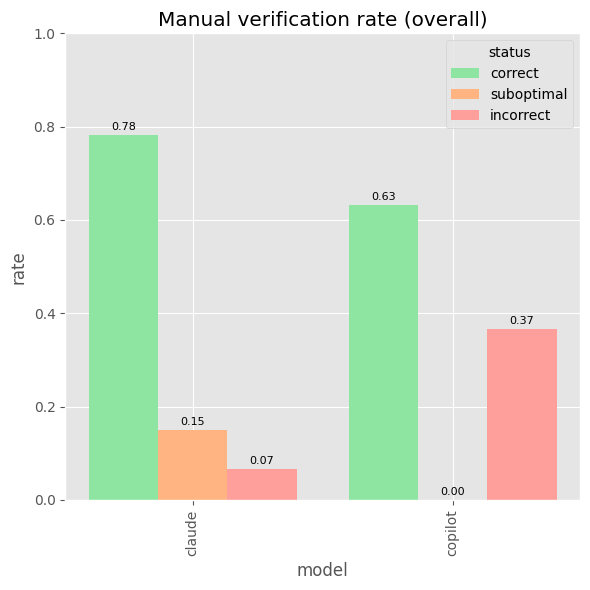

In [116]:
family_plot_df = family_rates[verification_order]

x = np.arange(len(family_plot_df.index))
n_bars = len(verification_order)
bar_width = 0.8 / n_bars

fig, ax = plt.subplots(figsize=(6, 6))

for i, status in enumerate(verification_order):
    offset = (i - (n_bars - 1) / 2) * bar_width
    bars = ax.bar(
        x + offset, family_plot_df[status], bar_width,
        label=status, color=colors[f"{status}_rate"],
    )
    ax.bar_label(bars, labels=[f"{v:.2f}" for v in family_plot_df[status]], padding=2, fontsize=8)

ax.set_xlabel("model")
ax.set_ylabel("rate")
ax.set_title("Manual verification rate (overall)")
ax.set_xticks(x)
ax.set_xticklabels(family_plot_df.index, rotation=90, ha="center")
ax.set_ylim(0, 1.0)
ax.legend(title="status")
fig.tight_layout()
plt.show()